# Principal Component Analysis (PCA)

A classical technique for uncovering the most informative directions in multivariate data through eigendecomposition of the covariance matrix.

<br>

<p align="center">
<img src="visualizations/PCA.png" width="1000">
</p>

## Mathematical Foundation

### The Covariance Matrix as a Data Operator

**Data Centering:**
$$
\widetilde{X} = X - \mathbf{1}\bar{x}^T, \quad \bar{x} = \frac{1}{n}\sum_i x_i
$$

**Covariance Matrix:**
$$
C = \frac{1}{n-1}\widetilde{X}^T\widetilde{X} \in \mathbb{R}^{m \times m}
$$

Where $C_{ij}$ measures how features $i$ and $j$ co-vary, and diagonals $C_{ii}$ are feature variances.

### Eigendecomposition: Extracting Axes and Variances

Solve:
$$
C v_i = \lambda_i v_i, \quad \lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_m \geq 0
$$

- **Eigenvectors** $v_i$: Principal directions ("principal axes") in feature space
- **Eigenvalues** $\lambda_i$: Variances of the data along $v_i$ 

Projecting each centered data point $\tilde{x}$ onto $v_i$ gives scalar $z_i = v_i^T\tilde{x}$ whose sample variance is exactly $\lambda_i$.

## Algorithm Steps

1. **Center the Data:** Subtract mean from each feature to ensure zero mean

2. **Compute Covariance Matrix:** Calculate pairwise feature covariance

3. **Eigendecomposition:** Solve $C v_i = \lambda_i v_i$ where:
   - **Eigenvectors** $v_i$: Principal directions in feature space
   - **Eigenvalues** $\lambda_i$: Variance along each direction
   - Order: $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_m \geq 0$

4. **Select Components:** Choose top $d$ eigenvectors that retain desired variance:
   $$
   \text{Variance Retained} = \frac{\sum_{i=1}^d \lambda_i}{\sum_{j=1}^m \lambda_j}
   $$

5. **Project Data:** Transform data to new coordinate system:
   $$
   Z = \widetilde{X} V_d \in \mathbb{R}^{n \times d}
   $$

## Advanced Topics

### Motivation & Key Applications

* **Dimensionality reduction:** Simplify high‑dimensional datasets by finding a lower‑dimensional representation that retains as much "spread" (variance) as possible
* **Noise filtering:** Remove small‑variance directions that often correspond to noise rather than signal
* **Visualization & interpretability:** Project data into 2D or 3D to inspect structure, clusters, and outliers

### Geometric Interpretation
* **Covariance Ellipsoid:** Image of unit sphere under $C$, elongated along high-variance directions
* **Principal Axes:** Eigenvectors align with ellipsoid's principal axes
* **Dimensionality Reduction:** Keep only the longest $d$ axes, projecting onto lower-dimensional hyperplane

### Reconstruction and Compression
**Reconstruction Error:** Data can be approximately reconstructed:
$$
X_{\text{reconstructed}} = Z V_d^T + \mathbf{1}\bar{x}^T
$$

**Compression Ratio:** Original $m$ dimensions → $d$ dimensions with controllable information loss

In [70]:
import numpy as np


def pca(X, n_components):
    """
    Perform PCA on dataset X and return the projected data onto top n_components.

    Parameters:
        X : ndarray of shape (n_samples, n_features)
            Input data (not necessarily centered)
        n_components : int
            Number of principal components to keep

    Returns:
        X_projected : ndarray of shape (n_samples, n_components)
            The data projected onto the top principal components
        components : ndarray of shape (n_components, n_features)
            The principal axes (top eigenvectors)
        explained_variance : ndarray of shape (n_components,)
            The eigenvalues corresponding to the selected components
    """
    # Step 1: Center the data (zero mean)
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean

    # Step 2: Compute the covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)

    # Step 3: Eigen decomposition of the covariance matrix
    eigvals, eigvecs = np.linalg.eigh(cov_matrix)

    # Step 4: Sort eigenvectors by descending eigenvalue
    sorted_idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[sorted_idx]
    eigvecs = eigvecs[:, sorted_idx]

    # Step 5: Select top n_components
    components = eigvecs[:, :n_components]
    explained_variance = eigvals[:n_components]

    # Step 6: Project the data
    X_projected = X_centered.dot(components)

    return X_projected, components.T, explained_variance



def reconstruct_pca(X_pca, components, X_mean):
    """Reconstruct the original data from PCA projected data.
    Parameters:
        X_pca : ndarray of shape (n_samples, n_components)
            The PCA projected data
        components : ndarray of shape (n_components, n_features)
            The principal axes (top eigenvectors)
        X_mean : ndarray of shape (n_features,)
            The mean of the original data
    Returns:
        X_reconstructed : ndarray of shape (n_samples, n_features)
            The reconstructed data from PCA
    """
    X_reconstructed = X_pca @ components + X_mean
    return X_reconstructed

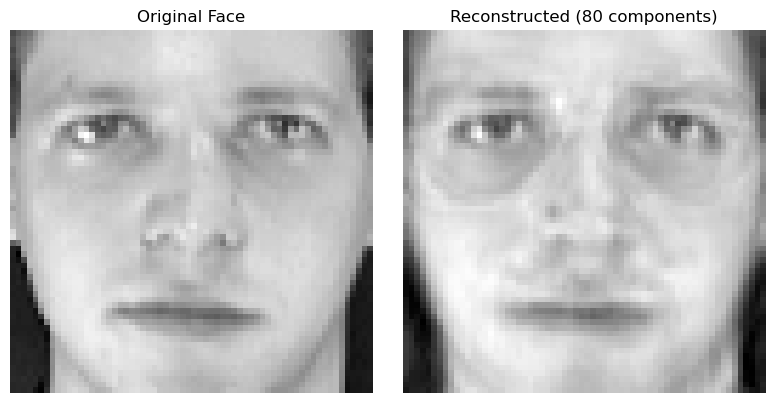

In [53]:
import matplotlib.pyplot as plt

n_components = 80  # Number of components to keep

# Step 1: Flatten the face images
data = np.load("Olivetti_faces/olivetti_faces.npy")
X = data.reshape(data.shape[0], -1)  # 400 faces of size 64x64

# Step 2: Perform PCA
X_pca, components, variances = pca(X, n_components=n_components)
X_mean = X.mean(axis=0)

# Step 3: Reconstruct
X_reconstructed = reconstruct_pca(X_pca, components, X_mean)

# Step 4: Show reconstructed image
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(X[0].reshape(64, 64), cmap="gray")
axs[0].set_title("Original Face")
axs[0].axis("off")

axs[1].imshow(X_reconstructed[0].reshape(64, 64), cmap="gray")
axs[1].set_title(f"Reconstructed ({n_components} components)")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## Eigenfaces

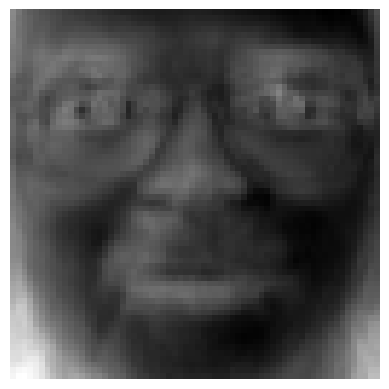

In [69]:
plt.imshow(components[0].reshape(64, 64), cmap="gray")
plt.axis("off")
plt.show()

## Determine best n_components

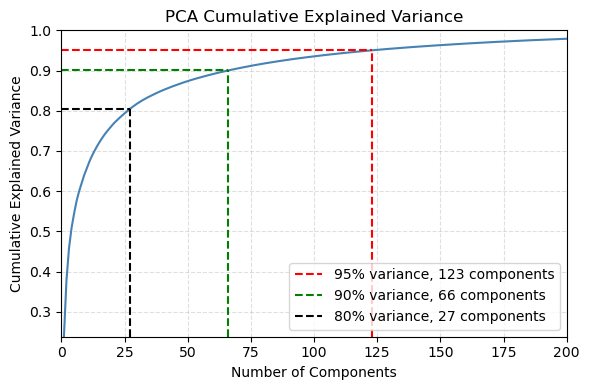

In [51]:
# Step 1: Compute all components first (not just top `n_components`)
_, _, all_variances = pca(X, n_components=X.shape[1])  # Use full rank

# Step 2: Compute cumulative explained variance ratio
explained_ratio = all_variances / np.sum(all_variances)
cumulative_variance = np.cumsum(explained_ratio)

# Plot elbow curve 
plt.figure(figsize=(6, 4))
plt.plot(
    np.arange(1, len(cumulative_variance) + 1), cumulative_variance, color="steelblue"
)
plt.xlim(0, 200)
plt.ylim(explained_ratio[0], 1.0)

# Variance thresholds lines
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_90 = np.argmax(cumulative_variance >= 0.9) + 1
n_80 = np.argmax(cumulative_variance >= 0.8) + 1

# Horizontal lines
plt.plot([0, n_95], [cumulative_variance[n_95 - 1]] * 2, color="r", linestyle="--")
plt.plot([0, n_90], [cumulative_variance[n_90 - 1]] * 2, color="green", linestyle="--")
plt.plot([0, n_80], [cumulative_variance[n_80 - 1]] * 2, color="black", linestyle="--")

# Vertical lines
plt.plot([n_95, n_95], [explained_ratio[0], cumulative_variance[n_95 - 1]], color="r", linestyle="--", label=f"95% variance, {n_95} components")
plt.plot([n_90, n_90], [explained_ratio[0], cumulative_variance[n_90 - 1]], color="green", linestyle="--", label=f"90% variance, {n_90} components")
plt.plot([n_80, n_80], [explained_ratio[0], cumulative_variance[n_80 - 1]], color="black", linestyle="--", label=f"80% variance, {n_80} components")


plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()